In [ ]:
pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 8.6 MB/s eta 0:00:00


# Online Diversity Metric Update
Using covariance trace as the diversity metric. Note that it is likely possible to make this faster by directly calculating variance and updating diversity.

In [ ]:
import numpy as np

# NOTE: we are using trace of covar matrix as diversity
# metric...but we could theoretically not compute matrix
# and sum variances only?

class OnlineCovTrace:
  def __init__(self, d: int):
    self.emb_dim = d
    self.t = 0
    self.mean = np.zeros(self.emb_dim, dtype=np.float32)
    self.cov_mat = np.zeros((self.emb_dim, self.emb_dim), dtype=np.float32)

  def add(self, x: np.ndarray):
    x = x.astype(np.float32)
    self.t += 1
    delta = x - self.mean
    self.mean += delta / self.t
    self.cov_mat += (np.outer(delta, delta) - self.cov_mat) / self.t

  @property
  def trace_cov_pop(self) -> float:
    return float(np.trace(self.cov_mat)) if self.t >= 2 else 0.0

  @property
  def trace_cov_unbiased(self) -> float:
    if self.t <= 1:
      return 0.0
    return float(np.trace(self.cov_mat) * self.t / (self.t - 1))

def batch_trace_unbiased(X):
    if len(X) <= 1:
        return 0.0
    cov = np.cov(np.array(X), rowvar=False, bias=False)  # 1/(n-1)
    return float(np.trace(cov))


# Online Mean Cosine Diversity Update

In [ ]:
import numpy as np

class OnlineCosineDiversity:
    def __init__(self, d: int):
        self.d = d
        self.t = 0
        self.sum_vec = np.zeros(d, dtype=np.float32)

    def add(self, x: np.ndarray):
        x = x.astype(np.float32)
        self.t += 1
        self.sum_vec += x

    @property
    def mean_cosine_distance(self) -> float:
        if self.t <= 1:
            return 0.0
        t = float(self.t)
        s2 = float(np.dot(self.sum_vec, self.sum_vec))
        mean_sim = (s2 - t) / (t * (t - 1))
        return 1.0 - mean_sim


Small test of online diversity calculation

In [ ]:
# X = np.array([
#     [0., 0.],
#     [2., 0.],
#     [2., 2.],
#     [4., 2.],
# ], dtype=np.float32)

# tracker = OnlineCovTrace(d=2)

# print(f"{'t':>2}  {'online':>10}  {'batch':>10}  {'diff':>10}")
# print("-" * 36)

# seen = []
# for t, x in enumerate(X, start=1):
#   seen.append(x)
#   tracker.add(x)
#   online = tracker.trace_cov_unbiased
#   batch = batch_trace_unbiased(seen)
#   diff = abs(online - batch)
#   print(f"{t:>2} {online:10.6f} {batch:10.6f} {diff:10.6f}")


# Creating a Gymnasium environment for DRL

In [ ]:
import gymnasium as gym
from gymnasium import spaces

class DiversitySelectionEnv(gym.Env):

  def __init__(self, X_embed: np.ndarray, M: int, d_metric: str | None = None, seed: int| None = None, maximize: bool = True):
    super().__init__()
    assert X_embed.ndim == 2 #(ds is dim. N, d)
    self.X = X_embed.astype(np.float32)
    self.N, self.d = self.X.shape
    self.X_embed = X_embed
    self.M = int(M) #from paper, target subset size
    self.rng = np.random.default_rng(seed)
    self.maximize = maximize
    self.observation_space = spaces.Box(
        low=-np.inf, high=np.inf, shape=(self.d,), dtype=np.float32
    )
    self.cum_reward = 0.0
    self.action_space = spaces.Discrete(2)
    self.cur_pos = None
    self.pool = None              #remaining indices of data to pick from
    self.selected = None          #indices of already picked datums
    self.div_tracker = None       #online diversity tracker
    self.cur_idx = None           #index of current datum being evaluated
    self.d_metric = d_metric

  def _sample_next(self):
    if self.pool.size == 0:
        return None
    self.cur_pos = int(self.rng.integers(0, self.pool.size))  # position inside pool array
    self.cur_idx = int(self.pool[self.cur_pos])               # dataset index
    return self.X[self.cur_idx]


  def reset(self, seed: int | None = None, options=None):
    super().reset(seed=seed)
    self.pool = np.arange(self.N)
    self.selected = []
    self.div_tracker = OnlineCosineDiversity(d=self.d) if self.d_metric == "cos" else OnlineCovTrace(d=self.d)
    self.cur_idx = None
    self.cur_pos = None
    self.cum_reward = 0.0

    obs = self._sample_next()
    if obs is None:
      obs = np.zeros(self.d, dtype=np.float32)
    return obs.astype(np.float32), {}

    # if len(self.pool) == 0:
    #   obs = np.zeros(self.d, dtype=np.float32)
    # else:
    #   i = int(self.rng.integers(0, len(self.pool)))
    #   self.cur_idx = int(self.pool[i])

    #   # swap-remove in O(1) time
    #   self.pool[i], self.pool[-1] = self.pool[-1], self.pool[i]
    #   self.pool = self.pool[:-1]

    #   obs = self.X[self.cur_idx]

    return obs.astype(np.float32), {}

  def step(self, action: int):
    """
    action: 0 = exclude, 1 = include curr. candidate
    returns: (obs, reward, terminated, truncated, info)
    """
    reward = 0.0

    if action == 1: #if we include...
      prev = self.div_tracker.mean_cosine_distance if self.d_metric == "cos" else self.div_tracker.trace_cov_unbiased #get diversity metric currently
      self.div_tracker.add(self.X[self.cur_idx]) #online update P1
      self.selected.append(self.cur_idx) #online update P2
      new = self.div_tracker.mean_cosine_distance if self.d_metric == "cos" else self.div_tracker.trace_cov_unbiased
      reward = new - prev #marginal diversity gain
      if not self.maximize:
        reward = -reward

      self.cum_reward += float(reward)

      last = self.pool[-1]
      self.pool[self.cur_pos] = last
      self.pool = self.pool[:-1]

    # M items picked, or nothing left to show
    terminated = (len(self.selected) >= self.M) or (len(self.pool) == 0)

    if terminated:
      obs = np.zeros(self.d, dtype=np.float32)

      info = {
        "selected_idx": np.array(self.selected, dtype=np.int32),
        "cum_reward": self.cum_reward,
      }
      if self.d_metric == "cos":
        info["d_metric"] = self.div_tracker.mean_cosine_distance
      else:
        info["d_metric"] = self.div_tracker.trace_cov_unbiased

      return obs, float(reward), True, False, info

    # # uniformly sample next candidate
    # i = int(self.rng.integers(0, len(self.pool)))
    # self.cur_idx = int(self.pool[i])

    # # swap-remove again
    # self.pool[i], self.pool[-1] = self.pool[-1], self.pool[i]
    # self.pool = self.pool[:-1]

    # obs = self.X[self.cur_idx]
    obs = self._sample_next()
    return obs.astype(np.float32), float(reward), False, False, {}


Testing environment with small example

In [ ]:
# X = X = np.array([
#     [0., 0.],
#     [2., 0.],
#     [2., 2.],
#     [4., 2.],
# ], dtype=np.float32)

# env = DiversitySelectionEnv(X_embed=X, M=3, seed=0)

# obs, info = env.reset()
# done = False
# episode_reward_sum = 0.0
# selected = []

# while not done:
#   obs, r, terminated, truncated, info = env.step(1)
#   episode_reward_sum += r
#   done = terminated or truncated
#   if not done:
#     selected.append(env.cur_idx)

# final_trace_pop = info["final_trace_pop"]
# sel_idx = info["selected_idx"]

# print("Sum of rewards               :", episode_reward_sum)
# print("Final trace (env, population)", final_trace_pop)
# print("Selected indices             :", sel_idx.tolist())

# sel = X[sel_idx]
# cov_pop = np.cov(sel, rowvar=False, bias=True)
# print("Batch trace (NumPy, pop)     :", float(np.trace(cov_pop)))


# Getting dataset + embeddings

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def build_fashion_mnist_embeddings(batch_size: int=512, device: str | None = None):
  if device is None:
    device = "cuda" if torch.cuda.is_available() else "cpu"

  transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.2860,), (0.3530,)),
      transforms.Lambda(lambda t: t.view(-1))
  ])

  ds = datasets.FashionMNIST(
      root="./data",
      train=True,
      download=True,
      transform=transform
  )

  loader = DataLoader(
      ds,
      batch_size=batch_size,
      shuffle=False,
      num_workers=2,
      pin_memory=True
  )

  X_list, y_list = [], []
  for imgs, labels in loader:
    X_list.append(imgs.float().cpu().numpy())
    y_list.append(labels.long().cpu().numpy())

  X_embed = np.concatenate(X_list, axis=0).astype(np.float32)
  y = np.concatenate(y_list, axis=0).astype(np.int64)

  return X_embed, y

X_embed, y = build_fashion_mnist_embeddings()
norms = np.linalg.norm(X_embed, axis=1, keepdims=True) + 1e-8
X_unit = (X_embed / norms).astype(np.float32)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.54MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.0MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


# Setting up RL agent
This is where the custom RL algorithm would replace PPO. For now, since PPO is SOTA and was used in the paper, we can use this.

Maximizing cosine diversity

In [ ]:
# from stable_baselines3 import PPO

# env_max = DiversitySelectionEnv(X_embed=X_unit, M=int(0.2 * len(X_embed)), seed=42)

# N = len(X_embed)
# M = int(0.2 * N)


# model_max = PPO(
#     policy="MlpPolicy",
#     env=env,
#     learning_rate=3e-4,
#     batch_size=64,
#     n_steps=2048,
#     n_epochs=10,
#     gamma=1.0,
#     gae_lambda=0.0,
# )

# #model.learn(total_timesteps=100_000, progress_bar=True)

Minimizing cosine diversity

In [ ]:
# from stable_baselines3 import PPO

# env_min = DiversitySelectionEnv(X_embed=X_unit, M=int(0.2 * len(X_embed)), seed=42, maximize=False)

# N = len(X_embed)
# M = int(0.2 * N)

# model = PPO(
#     policy="MlpPolicy",
#     env=env,
#     learning_rate=3e-4,
#     batch_size=64,
#     n_steps=2048,
#     n_epochs=10,
#     gamma=1.0,
#     gae_lambda=0.0,
# )

# model.learn(total_timesteps=100_000, progress_bar=True)

# Evaluating Agent in Environment

In [ ]:
# eval_env = DiversitySelectionEnv(X_embed=X_embed, M=M, seed=32)
# obs, info = eval_env.reset()

# done = False
# ep_reward = 0.0
# step_count = 0

# while not done:
#     action, _ = model.predict(obs, deterministic=True)
#     obs, reward, terminated, truncated, info = eval_env.step(int(action))
#     ep_reward += float(reward)
#     done = terminated or truncated
#     step_count += 1

# sel_idx = info["selected_idx"]
# final_trace = info["final_trace_pop"]
# env_cum = info["cum_reward"]

# batch_trace = float(np.trace(np.cov(X_embed[sel_idx], rowvar=False, bias=True)))
# print(f"Steps taken         : {step_count}")
# print(f"Selected count      : {len(sel_idx)}")
# print(f"Env cum_reward  : {env_cum:.6f}")
# print(f"Episode reward sum  : {ep_reward:.6f}")
# print(f"Final trace (env)   : {final_trace:.6f}")
# print(f"Batch trace (NumPy) : {batch_trace:.6f}")


# Creating selection mechanism (log-prob)

Includes helper functions for making line plots

In [ ]:
def mean_cosine_distance_for_indices(X_unit, idx):
    """
    X_unit: (N, d) L2-normalized.
    idx: 1D array/list of selected indices.
    """
    sel = X_unit[idx]
    t = sel.shape[0]
    if t <= 1:
        return 0.0
    s = sel.sum(axis=0)                 # sum of vectors
    s2 = float(np.dot(s, s))            # ||sum||^2
    mean_sim = (s2 - t) / (t * (t - 1)) # mean cosine similarity
    return 1.0 - mean_sim               # mean cosine distance


def inclusion_logprob(model, X, batch_size=8192, device=None):
  policy = model.policy
  device = device or next(policy.parameters()).device
  out = []
  with torch.no_grad():
    for i in range(0, len(X), batch_size):
      xb = torch.as_tensor(X[i:i+batch_size], dtype=torch.float32, device=device)
      dist = policy.get_distribution(xb)
      probs = dist.distribution.probs
      logp_inc = torch.log(probs[:, 1].clamp_min(1e-12))
      out.append(logp_inc.cpu().numpy())
  return np.concatenate(out, axis=0)

def rl_topM_indices(model, X_unit, M):
  logp = inclusion_logprob(model, X_unit)
  rank = np.argsort(-logp)
  return rank[:M]

def random_topM_indices(X_unit, M, rng=None):
  rng = rng or np.random.default_rng()
  return rng.choice(len(X_unit), size=M, replace=False)

def greedy_dpp_topM_indices(X_unit, M):
    raise NotImplementedError


# Compare this to random baseline...

In [ ]:
# import numpy as np

# def random_trace_baseline(X, M, trials=10, seed=0):
#     rng = np.random.default_rng(seed)
#     traces = []
#     for _ in range(trials):
#         idx = rng.choice(len(X), size=M, replace=False)
#         cov_pop = np.cov(X[idx], rowvar=False, bias=True)
#         traces.append(float(np.trace(cov_pop)))
#     return np.mean(traces), np.std(traces)

# mean_rand, std_rand = random_trace_baseline(X_embed, M, trials=10)
# print(f"Random-Top-{M}: mean trace.     = {mean_rand:.2f} ± {std_rand:.2f}")
# print(f"PPO Top-M trace.                = {750.83:.2f}")
# print(f"Improvement over random         = {((750.83 - mean_rand)/max(1e-9, mean_rand))*100:.1f}%")


# Recreating line plots from paper

In [ ]:
from stable_baselines3 import PPO
import gymnasium as gym

#Training
N = len(X_embed)
M_train = int(0.2 * N)
env_max = DiversitySelectionEnv(X_embed=X_unit, d_metric="trace", M=M_train, seed=42)
model_max = PPO(
    policy="MlpPolicy",
    env=env_max,
    learning_rate=3e-4,
    batch_size=64,
    n_steps=2048,
    n_epochs=10,
    gamma=1.0,
    gae_lambda=0.0,
)
model_max.learn(total_timesteps=100_000, progress_bar=True)

env_min = DiversitySelectionEnv(X_embed=X_unit, M=M_train, d_metric="trace", seed=42, maximize=False)
model_min = PPO(
    policy="MlpPolicy",
    env=env_min,
    learning_rate=3e-4,
    batch_size=64,
    n_steps=2048,
    n_epochs=10,
    gamma=1.0,
    gae_lambda=0.0,
)
model_min.learn(total_timesteps=100_000, progress_bar=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Output()

In [ ]:
size_percents = [2, 5, 10, 15, 20, 25, 30, 40, 50]
results_max = []
results_min = []
results_rand = []
results_dpp = []

for pct in size_percents:
  M = int(pct/100*N)
  print(f"=== Size {pct}% (M={M}) ===")

  idx_max = rl_topM_indices(model_max, X_unit, M)
  idx_min = rl_topM_indices(model_min, X_unit, M)

  rng = np.random.default_rng(0)
  idx_rand = random_topM_indices(X_unit, M, rng=rng)

  m_max = mean_cosine_distance_for_indices(X_unit, idx_max)
  m_min = mean_cosine_distance_for_indices(X_unit, idx_min)
  m_rand = mean_cosine_distance_for_indices(X_unit, idx_rand)

  results_max.append(m_max)
  results_min.append(m_min)
  results_rand.append(m_rand)

results_max = np.array(results_max)
results_min = np.array(results_min)
results_rand = np.array(results_rand)

=== Size 2% (M=1200) ===
=== Size 5% (M=3000) ===
=== Size 10% (M=6000) ===
=== Size 15% (M=9000) ===
=== Size 20% (M=12000) ===
=== Size 25% (M=15000) ===
=== Size 30% (M=18000) ===
=== Size 40% (M=24000) ===
=== Size 50% (M=30000) ===


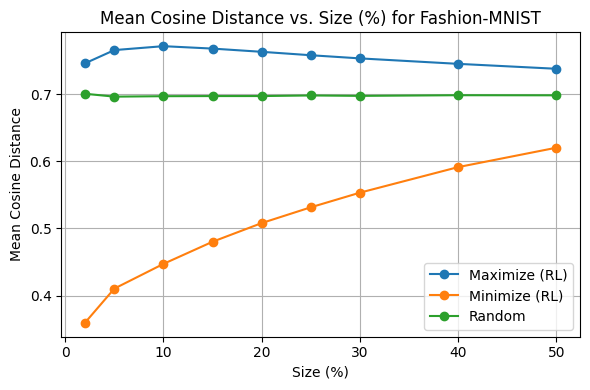

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(size_percents, results_max,  marker="o", label="Maximize (RL)")
plt.plot(size_percents, results_min,  marker="o", label="Minimize (RL)")
plt.plot(size_percents, results_rand, marker="o", label="Random")
# plt.plot(size_percents, results_dpp,  marker="o", label="Greedy DPP")  # when ready

plt.xlabel("Size (%)")
plt.ylabel("Mean Cosine Distance")
plt.title("Mean Cosine Distance vs. Size (%) for Fashion-MNIST")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Extending to CIFAR-10

In [ ]:
pip install torch

ResNet-18 Feature Extractor

In [ ]:
from torchvision import datasets, transforms, models
from torch import nn

def build_resnet18_feature_extractor(device=None):
  if device is None:
    device = "cuda" if torch.cuda.is_available() else "cpu"

  weights = models.ResNet18_Weights.IMAGENET1K_V1
  base = models.resnet18(weights=weights)
  base.eval()

  class ResNet18Features(nn.Module):
    def __init__(self, backbone):
      super().__init__()
      #all layers except final fc layer
      self.backbone = nn.Sequential(*list(backbone.children())[:-1])

    def forward(self, x):
      x = self.backbone(x)
      x = torch.flatten(x, 1)
      return x

  model = ResNet18Features(base).to(device)
  model.eval()
  return model, weights.transforms(), device

Putting it together


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models


def build_cifar10_resnet_embeddings(batch_size=256):
  model, resnet_transform, device = build_resnet18_feature_extractor()

  ds = datasets.CIFAR10(
      root="./data_cifar",
      train=True,
      download=True,
      transform=resnet_transform
  )

  loader = DataLoader(
      ds,
      batch_size=batch_size,
      shuffle=False,
      num_workers=2,
      pin_memory=True
  )

  X_list, y_list = [], []

  with torch.no_grad():
    for imgs, labels in loader:
      imgs = imgs.to(device)
      feats = model(imgs)
      X_list.append(feats.cpu().numpy())
      y_list.append(labels.numpy())

  X_embed = np.concatenate(X_list, axis=0).astype(np.float32)
  y = np.concatenate(y_list, axis=0).astype(np.int64)
  return X_embed, y

X_embed_cifar, y_cifar = build_cifar10_resnet_embeddings()

# raw features for trace(Cov) training
X_raw_cifar = X_embed_cifar

# unit-norm copy for mean-cosine evaluation
norms = np.linalg.norm(X_embed_cifar, axis=1, keepdims=True) + 1e-8
X_unit_cifar = (X_embed_cifar / norms).astype(np.float32)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]
100%|██████████| 170M/170M [00:03<00:00, 49.1MB/s]


In [ ]:
from stable_baselines3 import PPO
import gymnasium as gym


#Training
N_cifar = len(X_raw_cifar)
M_cifar_train = int(0.2 * N_cifar)
env_cifar_max = DiversitySelectionEnv(
    X_embed=X_raw_cifar,
    d_metric="trace",
    M=M_cifar_train,
    seed=42,
    maximize=True
)
model_cifar_max = PPO(
    policy="MlpPolicy",
    env=env_cifar_max,
    learning_rate=3e-4,
    batch_size=64,
    n_steps=2048,
    n_epochs=10,
    gamma=1.0,
    gae_lambda=0.0,
)

model_cifar_max.learn(total_timesteps=100_000, progress_bar=True)

env_cifar_min = DiversitySelectionEnv(
    X_embed=X_raw_cifar,
    d_metric="trace",
    M=M_cifar_train,
    seed=42,
    maximize=False
)
model_cifar_min = PPO(
    policy="MlpPolicy",
    env=env_cifar_min,
    learning_rate=3e-4,
    batch_size=64,
    n_steps=2048,
    n_epochs=10,
    gamma=1.0,
    gae_lambda=0.0,
)

model_cifar_min.learn(total_timesteps=100_000, progress_bar=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Output()

In [ ]:
size_percents = [2, 5, 10, 15, 20, 25, 30, 40, 50]
results_max = []
results_min = []
results_rand = []
results_dpp = []

for pct in size_percents:
  M = int(pct/100*N_cifar)
  print(f"=== Size {pct}% (M={M}) ===")

  idx_max = rl_topM_indices(model_cifar_max, X_unit_cifar, M)
  idx_min = rl_topM_indices(model_cifar_min, X_unit_cifar, M)

  rng = np.random.default_rng(0)
  idx_rand = random_topM_indices(X_unit_cifar, M, rng=rng)

  m_max = mean_cosine_distance_for_indices(X_unit_cifar, idx_max)
  m_min = mean_cosine_distance_for_indices(X_unit_cifar, idx_min)
  m_rand = mean_cosine_distance_for_indices(X_unit_cifar, idx_rand)

  results_max.append(m_max)
  results_min.append(m_min)
  results_rand.append(m_rand)

results_max = np.array(results_max)
results_min = np.array(results_min)
results_rand = np.array(results_rand)

=== Size 2% (M=1000) ===
=== Size 5% (M=2500) ===
=== Size 10% (M=5000) ===
=== Size 15% (M=7500) ===
=== Size 20% (M=10000) ===
=== Size 25% (M=12500) ===
=== Size 30% (M=15000) ===
=== Size 40% (M=20000) ===
=== Size 50% (M=25000) ===


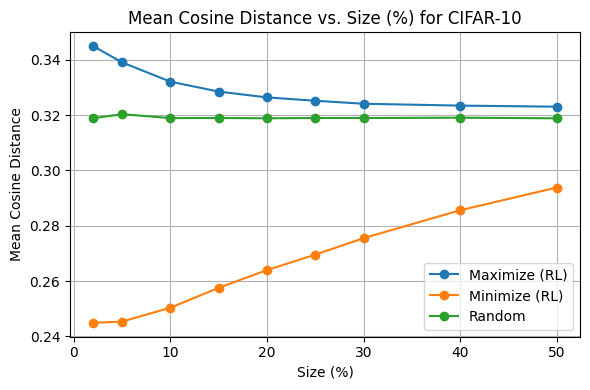

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(size_percents, results_max,  marker="o", label="Maximize (RL)")
plt.plot(size_percents, results_min,  marker="o", label="Minimize (RL)")
plt.plot(size_percents, results_rand, marker="o", label="Random")
# plt.plot(size_percents, results_dpp,  marker="o", label="Greedy DPP")  # when ready

plt.xlabel("Size (%)")
plt.ylabel("Mean Cosine Distance")
plt.title("Mean Cosine Distance vs. Size (%) for CIFAR-10")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Alpaca

In [ ]:
pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 17.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.


Loading Alpaca Dataset

In [ ]:
from datasets import load_dataset

alpaca_ds = load_dataset("yahma/alpaca-cleaned")

train_ds = alpaca_ds["train"]

texts = []
for ex in train_ds:
  instr = ex["instruction"].strip()
  inp = ex["input"].strip()
  if inp:
    txt = instr + " " + inp
  else:
    txt = instr
  texts.append(txt)

print("Num Alpaca examples:", len(texts))
print("Example text:", texts[0][:200], "...")

Num Alpaca examples: 51760
Example text: Give three tips for staying healthy. ...


Creating embeddings using SentenceTransformers

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np

mpnet = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

X_embed_alpaca = mpnet.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
).astype(np.float32)

print("Alpaca embeddings shape:", X_embed_alpaca.shape)

norms = np.linalg.norm(X_embed_alpaca, axis=1, keepdims=True) + 1e-8
X_unit_alpaca = (X_embed_alpaca / norms).astype(np.float32)

Batches:   0%|          | 0/809 [00:00<?, ?it/s]

Alpaca embeddings shape: (51760, 768)


In [ ]:
from stable_baselines3 import PPO
import gymnasium as gym


#Training
N_alpaca = len(X_embed_alpaca)
M_alpaca_train = int(0.2 * N_alpaca)
env_alpaca_max = DiversitySelectionEnv(
    X_embed=X_unit_alpaca,
    d_metric="cos",
    M=M_alpaca_train,
    seed=42,
    maximize=True
)
model_alpaca_max = PPO(
    policy="MlpPolicy",
    env=env_alpaca_max,
    learning_rate=3e-4,
    batch_size=64,
    n_steps=2048,
    n_epochs=10,
    gamma=1.0,
    gae_lambda=0.0,
)

model_alpaca_max.learn(total_timesteps=100_000, progress_bar=True)

env_alpaca_min = DiversitySelectionEnv(
    X_embed=X_unit_alpaca,
    d_metric="cos",
    M=M_alpaca_train,
    seed=42,
    maximize=False
)
model_alpaca_min = PPO(
    policy="MlpPolicy",
    env=env_alpaca_min,
    learning_rate=3e-4,
    batch_size=64,
    n_steps=2048,
    n_epochs=10,
    gamma=1.0,
    gae_lambda=0.0,
)

model_alpaca_min.learn(total_timesteps=100_000, progress_bar=True)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Output()

In [ ]:
import torch

size_percents = [2, 5, 10, 15, 20, 25, 30, 40, 50]
results_max = []
results_min = []
results_rand = []
results_dpp = []

for pct in size_percents:
  M = int(pct/100*N_alpaca)
  print(f"=== Size {pct}% (M={M}) ===")

  idx_max = rl_topM_indices(model_alpaca_max, X_unit_alpaca, M)
  idx_min = rl_topM_indices(model_alpaca_min, X_unit_alpaca, M)

  rng = np.random.default_rng(0)
  idx_rand = random_topM_indices(X_unit_alpaca, M, rng=rng)

  m_max = mean_cosine_distance_for_indices(X_unit_alpaca, idx_max)
  m_min = mean_cosine_distance_for_indices(X_unit_alpaca, idx_min)
  m_rand = mean_cosine_distance_for_indices(X_unit_alpaca, idx_rand)

  results_max.append(m_max)
  results_min.append(m_min)
  results_rand.append(m_rand)

results_max = np.array(results_max)
results_min = np.array(results_min)
results_rand = np.array(results_rand)

=== Size 2% (M=1035) ===
=== Size 5% (M=2588) ===
=== Size 10% (M=5176) ===
=== Size 15% (M=7764) ===
=== Size 20% (M=10352) ===
=== Size 25% (M=12940) ===
=== Size 30% (M=15528) ===
=== Size 40% (M=20704) ===
=== Size 50% (M=25880) ===


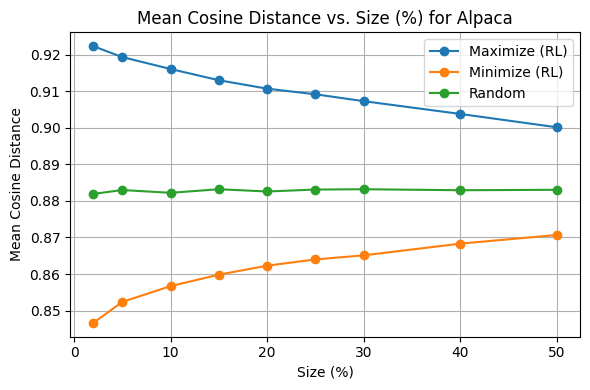

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(size_percents, results_max,  marker="o", label="Maximize (RL)")
plt.plot(size_percents, results_min,  marker="o", label="Minimize (RL)")
plt.plot(size_percents, results_rand, marker="o", label="Random")
# plt.plot(size_percents, results_dpp,  marker="o", label="Greedy DPP")  # when ready

plt.xlabel("Size (%)")
plt.ylabel("Mean Cosine Distance")
plt.title("Mean Cosine Distance vs. Size (%) for Alpaca")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()